# A Light Weight Multi-Distance fNIRS Dataset for Ball-Squeezing Task and Purposeful Motion Artifact Creation

# Imports

In [2]:
# PyTorch
import torch 
import torch.nn as nn
import torch.nn.functional as nnFunc
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch
import torch.onnx
# Check the hardware
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"CUDA Version: {torch.version.cuda}")
# Tensorflow
import tensorflow as tf
# General
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
# Read Dataset
import mne
import mne_nirs
import os
import openneuro


Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5050 Laptop GPU
CUDA Version: 13.0


# Helper Functions

In [3]:
def print_red(text):
  print(f"\033[31m{text}\033[0m")
def print_green(text):
  print(f"\033[32m{text}\033[0m")
def print_yellow(text):
  print(f"\033[33m{text}\033[0m")

## Dataset
[link](https://openneuro.org/datasets/ds007420) to dataset

### 1. Download Dataset

In [4]:
datasetID = 'ds007420'
targetFolder = './heg_full_data'

markerFile = os.path.join(targetFolder, 'dataset_description.json')

# Check if the folder and the marker file exist
if os.path.exists(targetFolder) and os.path.isfile(markerFile):
    print_green(f"Dataset {datasetID} already exists in '{targetFolder}'. Skipping download.")
else:
    print_yellow(f"Dataset not found or incomplete. Starting download to '{targetFolder}'...")
    try:
        # The openneuro-py library will fetch the actual binary data
        openneuro.download(dataset=datasetID, target_dir=targetFolder)
        print("Download successfully completed!")
    except Exception as e:
        print(f"An error occurred during download: {e}")

Dataset ds007420 already exists in './heg_full_data'. Skipping download.


### 1. Load Dataset

Loading d:\Education\PhD\Courses\3_DeepLearning\Assignments\Repo\202610ELC536501\Project\heg_full_data\sub-170\ses-01\nirs\sub-170_ses-01_task-Resting_nirs.snirf
Found jitter of 0.000000% in sample times.
Reading 0 ... 2655  =      0.000 ...   304.497 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.01 - 0.7 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.01
- Lower transition bandwidth: 0.01 Hz (-6 dB cutoff frequency: 0.01 Hz)
- Upper passband edge: 0.70 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.70 Hz)
- Filter length: 2879 samples (330.187 s)

Using matplotlib as 2D backend.


C:\Users\kaveh\AppData\Local\Temp\ipykernel_9400\2627534969.py:9: RuntimeWarning: filter_length (2879) is longer than the signal (2656), distortion is likely. Reduce filter length or filter a longer signal.
  rawOD.filter(0.01, 0.7, fir_design='firwin')


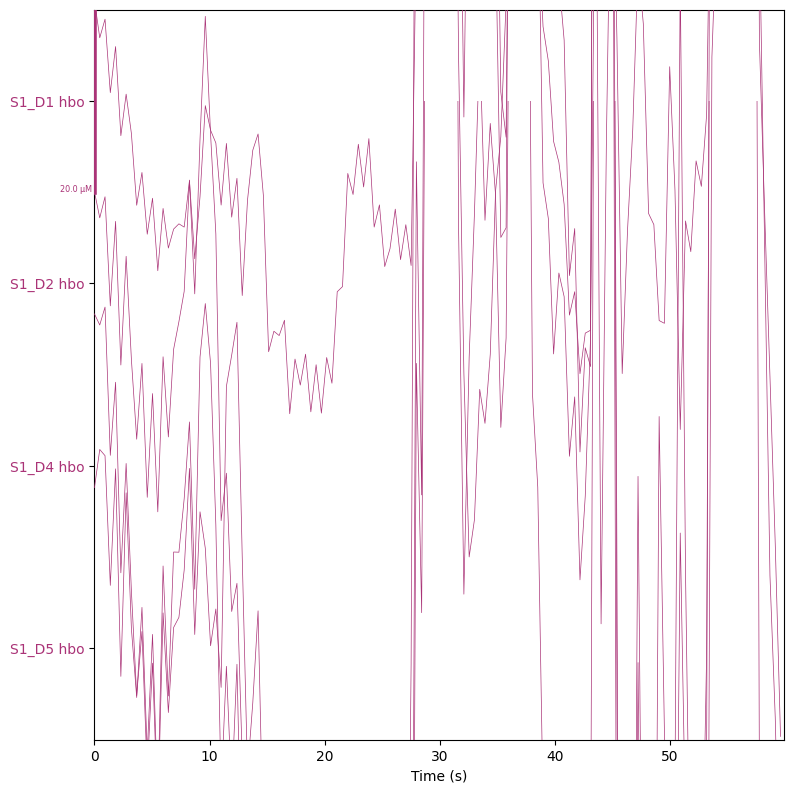

Data shape for ML: (200, 2656)


In [5]:
# 1. Load the dataset
filePath = f'{targetFolder}/sub-170/ses-01/nirs/sub-170_ses-01_task-Resting_nirs.snirf'
raw_intensity = mne.io.read_raw_snirf(filePath, preload=True)

# 2. Convert Raw Intensity to Optical Density (OD)
rawOD = mne.preprocessing.nirs.optical_density(raw_intensity)

# 3. Clean the data (Crucial for your Deep Learning input)
rawOD.filter(0.01, 0.7, fir_design='firwin')

# 4. Convert Optical Density to Hemoglobin (HbO and HbR)
rawHEMO = mne.preprocessing.nirs.beer_lambert_law(rawOD, ppf=0.1)

# 5. Visualize the cleaned signal
rawHEMO.plot(n_channels=4, duration=60, show_scrollbars=False)
plt.show()

# 6. Prepare data for Deep Learning (NumPy Conversion)
data = rawHEMO.get_data() # Shape: (channels, time_points)
print(f"Data shape for ML: {data.shape}")

### 2. Function Definitions Compatible With Hardware

In [6]:
def MCU_Filter_EMAHighpass(raw_epochs, shift_bits=8):
  """
  Simulates the integer-based EMA DC-blocking filter of the MCU.
  Expects input shape: (Trials, Channels, Time)
  """
  alpha = 1.0 / (2 ** shift_bits) 
  ema_baseline = np.zeros_like(raw_epochs)
  ema_baseline[:, :, 0] = raw_epochs[:, :, 0] # Initialize
    
  for t in range(1, raw_epochs.shape[2]):
    ema_baseline[:, :, t] = ema_baseline[:, :, t-1] + alpha * (raw_epochs[:, :, t] - ema_baseline[:, :, t-1])
        
  ac_signal = raw_epochs - ema_baseline
  return ac_signal

### 3. Preparing The Dataset

In [7]:
# Choosing first 10 subjects out of 12 for training
trainSubjects = ['170', '171', '173', '174', '176', '177', '179', '181', '182', '183'] # 10 out of 12
# Map sessions/tasks to specific class labels
# Class 0: Rest | Class 1: Ball Squeeze | Class 2: Motion Artifact
taskConfig = [
  {'ses': 'ses-01', 'task': 'task-Resting', 'label': 0, 'runs': [None]},
  {'ses': 'ses-02', 'task': 'task-BallSqueezing', 'label': 1, 'runs': ['run-01', 'run-02', 'run-03']},
  {'ses': 'ses-03', 'task': 'task-Motion', 'label': 2, 'runs': [None]}
]

X_TrainList = []
y_TrainList = []

print_yellow(f"Starting Edge-AI Data Extraction for {len(trainSubjects)} training subjects...")

for sub in trainSubjects:
  print(f"Processing Subject {sub}...")
  
  for config in taskConfig:
    for run in config['runs']:
      run_str = f"_{run}" if run else ""
      fileName = f"sub-{sub}_{config['ses']}_{config['task']}{run_str}_nirs.snirf"
      filePath = os.path.join(targetFolder, f"sub-{sub}", config['ses'], 'nirs', fileName)

      if not os.path.exists(filePath):
        print_red(f"  - Missing: {fileName}") # Don't remove this. This is for debugging
        continue
      
      try:
        # 1. Load Raw
        raw = mne.io.read_raw_snirf(filePath, preload=True, verbose=False)
        
        # 2. RESAMPLE TO 10 Hz - Make the shape uniform.
        raw.resample(10.0)
        
        # 3. Extract Events
        if config['label'] in [0, 2]: 
          events = mne.make_fixed_length_events(raw, id=config['label'], duration=15.0)
          event_dict = {'Segment': config['label']}
        else:
          events, event_dict = mne.events_from_annotations(raw, verbose=False)

        # 4. Epoching (12-second windows)
        epochs = mne.Epochs(raw, events, tmin=0, tmax=12.0, 
                            baseline=None, preload=True, verbose=False)
        
        eData = epochs.get_data()
        
        # Ensure we only keep full 12-second windows (120+ samples)
        if eData.shape[2] < 120: 
          continue

        X_TrainList.append(eData)
        y_TrainList.append(np.full(len(eData), config['label']))
          
      except Exception as e:
        print_red(f"  - Error in {fileName}: {e}")

# 5. Final Concatenation
if X_TrainList:
  X_Raw = np.concatenate(X_TrainList, axis=0)
  
  # FIXED TYPO: This must concatenate y_TrainList, not X_TrainList
  y_Raw = np.concatenate(y_TrainList, axis=0) 
  
  # Simulate MCU High-Pass Filter
  X_Filtered = MCU_Filter_EMAHighpass(X_Raw, shift_bits=8)
  
  print_green("\nExtraction Successful!")
  print(f"Total Samples: {X_Filtered.shape[0]}")
  print(f"Signal Windows: {X_Filtered.shape[2]} time points per sample")
  print(f"Class Distribution: {np.bincount(y_Raw)}")
else:
  print_red("No data was loaded. Please check if the 'target_folder' path is correct.")

Starting Edge-AI Data Extraction for 10 training subjects...
Processing Subject 170...
Processing Subject 171...
Processing Subject 173...
Processing Subject 174...
Processing Subject 176...
Processing Subject 177...
Processing Subject 179...
Processing Subject 181...
Processing Subject 182...
Processing Subject 183...

Extraction Successful!
Total Samples: 1409
Signal Windows: 121 time points per sample
Class Distribution: [198 900 311]


### 4. Autoencoder

In [8]:
class EdgeHEG_Autoencoder(nn.Module):
  def __init__(self, num_channels):
    super(EdgeHEG_Autoencoder, self).__init__()
    
    # ENCODER (Compressing the wave)
    # Input: (Batch, Channels, 120) -> Output: (Batch, 16, 60)
    self.enc_conv1 = nn.Conv1d(in_channels=num_channels, out_channels=16, kernel_size=11, padding=5)
    self.enc_pool1 = nn.MaxPool1d(kernel_size=2) 
    
    # Input: (Batch, 16, 60) -> Output: (Batch, 32, 30)
    self.enc_conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
    self.enc_pool2 = nn.MaxPool1d(kernel_size=2)
    
    # DECODER (Rebuilding the wave)
    # Input: (Batch, 32, 30) -> Output: (Batch, 16, 60)
    self.dec_upconv1 = nn.ConvTranspose1d(in_channels=32, out_channels=16, kernel_size=2, stride=2)
    
    # Input: (Batch, 16, 60) -> Output: (Batch, Channels, 120)
    self.dec_upconv2 = nn.ConvTranspose1d(in_channels=16, out_channels=num_channels, kernel_size=2, stride=2)

  def forward(self, x):
    # Encode
    x = self.enc_pool1(torch.relu(self.enc_conv1(x)))
    x = self.enc_pool2(torch.relu(self.enc_conv2(x)))
    
    # Decode
    x = torch.relu(self.dec_upconv1(x))
    # No ReLU on the final layer because the clean AC signal can be negative!
    x = self.dec_upconv2(x) 
    return x

### 5. Instantiate the model

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = EdgeHEG_Autoencoder(num_channels=X_Filtered.shape[1]).to(device)
print(autoencoder)

EdgeHEG_Autoencoder(
  (enc_conv1): Conv1d(200, 16, kernel_size=(11,), stride=(1,), padding=(5,))
  (enc_pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc_conv2): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (enc_pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dec_upconv1): ConvTranspose1d(32, 16, kernel_size=(2,), stride=(2,))
  (dec_upconv2): ConvTranspose1d(16, 200, kernel_size=(2,), stride=(2,))
)


In [10]:
# Create the targets (Y) - The cleanest data we have
# We exclude the 'Motion' class data from this because we don't want the AI 
# learning that actual motion spikes are a "clean" target.
clean_indices = (y_Raw == 0) | (y_Raw == 1) # Only Rest and Squeeze
Y_clean_target = X_Filtered[clean_indices]

# Find the global standard deviation of your clean data
signal_scale = np.std(Y_clean_target)
# Divide everything by this scale to normalize the amplitude to ~1.0
Y_clean_target = Y_clean_target / signal_scale

# Create the Inputs (X) - Injecting severe synthetic noise
noise_level = 0.5 * np.std(Y_clean_target) # Note: np.std is now basically 1.0!
X_noisy_input = Y_clean_target + np.random.normal(0, noise_level, Y_clean_target.shape)

# Optional: Add simulated "Motion Spikes" to random channels to make it harder
spike_mask = np.random.choice([0, 1], size=Y_clean_target.shape, p=[0.98, 0.02])
X_noisy_input += spike_mask * 2.0

class AutoencoderDataset(Dataset):
  def __init__(self, noisy_x, clean_y):
    self.x = torch.tensor(noisy_x, dtype=torch.float32)
    self.y = torch.tensor(clean_y, dtype=torch.float32) # Notice y is now float32, not long!
      
  def __len__(self):
    return len(self.x)
  
  def __getitem__(self, idx):
    return self.x[idx], self.y[idx]

# Create new DataLoader
ae_dataset = AutoencoderDataset(X_noisy_input, Y_clean_target)
ae_loader = DataLoader(ae_dataset, batch_size=32, shuffle=True)

print_green(f"Filter Data Prepared! {len(ae_dataset)} Waveform Pairs Ready.")

Filter Data Prepared! 1098 Waveform Pairs Ready.


### 6. Training

In [11]:
class ShapeAwareLoss(nn.Module):
  def __init__(self, alpha=0.5):
    super(ShapeAwareLoss, self).__init__()
    self.mse = nn.MSELoss()
    self.alpha = alpha # Controls how much we care about the slope

  def forward(self, pred, target):
    # 1. Standard Point-wise Error
    loss_mse = self.mse(pred, target)
    
    # 2. Derivative Error (Difference between adjacent time steps)
    # This captures the "slope" or "velocity" of the wave
    pred_diff = pred[:, :, 1:] - pred[:, :, :-1]
    target_diff = target[:, :, 1:] - target[:, :, :-1]
    loss_slope = self.mse(pred_diff, target_diff)
    
    # Combine them
    return loss_mse + (self.alpha * loss_slope)

In [12]:
import torch.optim as optim

epochs = 50
learning_rate = 0.002

# MSE measures the distance between the reconstructed wave and the true wave
criterion = ShapeAwareLoss(alpha=0.5)
optimizer = optim.Adam(autoencoder.parameters(), lr=learning_rate)

# This will cut the learning rate in half every 15 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

print_green("Training the AI Filter...")
loss_history = []

for epoch in range(epochs):
  autoencoder.train()
  running_loss = 0.0
  
  for inputs, targets in ae_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    
    optimizer.zero_grad()
    
    # Forward pass: AI attempts to clean the noisy input
    reconstructed_wave = autoencoder(inputs)
    
    # Slice the target so its length matches the AI's output length
    targets = targets[:, :, :reconstructed_wave.size(2)]
    
    # Compare the AI's wave to the perfect target wave
    loss = criterion(reconstructed_wave, targets)
    
    loss.backward()
    optimizer.step()
    
    running_loss += loss.item() * inputs.size(0)
      
  epoch_loss = running_loss / len(ae_dataset)
  loss_history.append(epoch_loss)
  
  if (epoch + 1) % 5 == 0 or epoch == 0:
    print_yellow(f"Epoch [{epoch+1}/{epochs}] | MSE Loss: {epoch_loss:.6f}")
  
  scheduler.step()

print_green("AI Filter Training Complete!")

Training the AI Filter...
Epoch [1/50] | MSE Loss: 0.818425
Epoch [5/50] | MSE Loss: 0.501265
Epoch [10/50] | MSE Loss: 0.372980
Epoch [15/50] | MSE Loss: 0.356949
Epoch [20/50] | MSE Loss: 0.297727
Epoch [25/50] | MSE Loss: 0.288814
Epoch [30/50] | MSE Loss: 0.287001
Epoch [35/50] | MSE Loss: 0.272687
Epoch [40/50] | MSE Loss: 0.266660
Epoch [45/50] | MSE Loss: 0.259583
Epoch [50/50] | MSE Loss: 0.253190
AI Filter Training Complete!


### 7. Testing

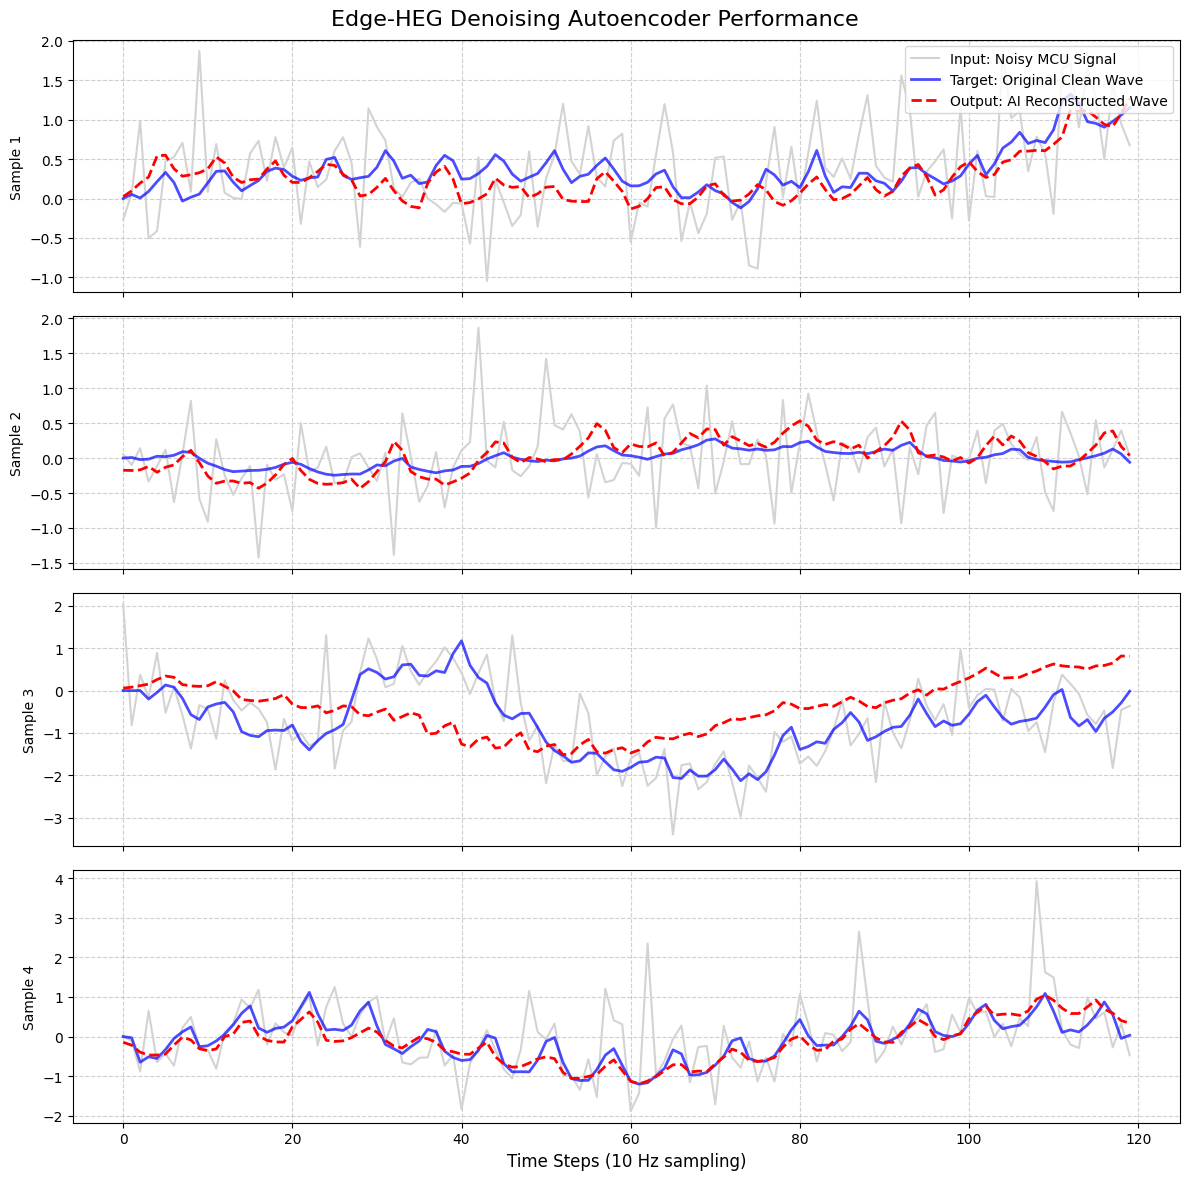

In [13]:
# 1. Put the model into Evaluation Mode
autoencoder.eval()

# 2. Grab a single batch from the DataLoader
with torch.no_grad():
  sample_noisy, sample_clean = next(iter(ae_loader))
  sample_noisy = sample_noisy.to(device)
  
  # Run the noisy data through the AI Filter
  reconstructed_wave = autoencoder(sample_noisy)

# 3. Move the tensors back to the CPU and convert to NumPy
noisy_np = sample_noisy.cpu().numpy()
clean_np = sample_clean.cpu().numpy()
recon_np = reconstructed_wave.cpu().numpy()

# --- Apply the Tensor Slicing Fix ---
min_len = min(noisy_np.shape[2], clean_np.shape[2], recon_np.shape[2])
noisy_np = noisy_np[:, :, :min_len]
clean_np = clean_np[:, :, :min_len]
recon_np = recon_np[:, :, :min_len]

# 4. Plot multiple samples in a grid
num_plots = 4 # Change this to see more or fewer examples
channel_idx = 0

# Create a figure with multiple subplots stacked vertically
fig, axes = plt.subplots(num_plots, 1, figsize=(12, 3 * num_plots), sharex=True)

for i in range(num_plots):
    # Plot Noisy Input
    axes[i].plot(noisy_np[i, channel_idx, :], 
             label='Input: Noisy MCU Signal', 
             color='lightgray', linewidth=1.5)

    # Plot Clean Target
    axes[i].plot(clean_np[i, channel_idx, :], 
             label='Target: Original Clean Wave', 
             color='blue', linewidth=2, alpha=0.7)

    # Plot AI Output
    axes[i].plot(recon_np[i, channel_idx, :], 
             label='Output: AI Reconstructed Wave', 
             color='red', linestyle='dashed', linewidth=2)
    
    axes[i].set_ylabel(f"Sample {i+1}", fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    
    # Only put the legend on the top plot to keep it clean
    if i == 0:
        axes[i].legend(loc="upper right")

# Set the overall titles and labels
axes[-1].set_xlabel("Time Steps (10 Hz sampling)", fontsize=12)
fig.suptitle("Edge-HEG Denoising Autoencoder Performance", fontsize=16, y=0.98)

plt.tight_layout()
plt.show()

### 8. To Hardware

In [16]:
import onnx
# Move the model off the GPU and onto the CPU, as your MCU doesn't have a GPU!
autoencoder.cpu()

# Lock the model into evaluation mode (turns off Dropout and gradients)
autoencoder.eval() 

# The Cortex-M33 will process exactly one 12-second window at a time.
# Shape: (Batch=1, Channels=numChannels, TimeSteps=120)
dummy_mcu_input = torch.randn(1, X_Filtered.shape[1], 120)

onnx_file_path = "edge_heg_autoencoder.onnx"

print("Tracing the computation graph...")

torch.onnx.export(
    autoencoder,                  # The trained PyTorch model
    dummy_mcu_input,              # The fake data to trace the math
    onnx_file_path,               # The output filename
    export_params=True,           # Save the trained weights, not just the architecture
    opset_version=11,             # Opset 11 is highly stable for Edge/Microcontroller conversion
    do_constant_folding=True,     # Optimization: Pre-calculates constant math to save MCU clock cycles
    input_names=['rawMcuWave'], # Naming the input array for your C-code
    output_names=['cleanWave'],  # Naming the output array for your C-code
)

print_green(f"Model architecture and weights successfully exported to '{onnx_file_path}'")

# Load the ONNX model back in and check for graph errors
onnx_model = onnx.load(onnx_file_path)
onnx.checker.check_model(onnx_model)
print_green("ONNX model verified and mathematically sound!")

W0506 12:38:43.108000 9400 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


Tracing the computation graph...
[torch.onnx] Obtain model graph for `EdgeHEG_Autoencoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EdgeHEG_Autoencoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


C:\Python312\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "d:\Education\PhD\Courses\3_DeepLearning\Assignments\Repo\202610ELC536501\.venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Education\PhD\Courses\3_DeepLearning\Assignments\Repo\202610ELC536501\.venv\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Model architecture and weights successfully exported to 'edge_heg_autoencoder.onnx'
ONNX model verified and mathematically sound!


### 9. To Hardware 2

In [15]:
# ==========================================
# 1. ONNX to TensorFlow SavedModel (The Modern Way)
# ==========================================
print("1. Converting ONNX to TensorFlow SavedModel...")
onnx_model_path = "edge_heg_autoencoder.onnx"
tf_model_dir = "tf_saved_model"

# Convert the ONNX model to a TensorFlow SavedModel
onnx2tf.convert(
    input_onnx_file_path=onnx_model_path,
    output_folder_path=tf_model_dir,
    copy_onnx_input_output_names_to_tflite=True,
    non_verbose=True
)
print("SavedModel generated successfully!")

# ==========================================
# 2. TensorFlow to TFLite (INT8 Quantization)
# ==========================================
print_yellow("\n2. Quantizing to INT8 TFLite...")
converter = tf.lite.TFLiteConverter.from_saved_model(tf_model_dir)

# Enable aggressive size optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# The Quantization Magic: Feed it 100 real samples to calculate Min/Max bounds
def representative_data_gen():
    # Grab 100 samples from your normalized, noisy input array
    for i in range(100):
        sample = X_noisy_input[i:i+1].astype(np.float32)
        yield [sample]

converter.representative_dataset = representative_data_gen

# Force strict INT8 quantization for the Cortex-M33 DSP unit
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Convert and save the binary file
tflite_quant_model = converter.convert()
tflite_file_name = "edge_heg_autoencoder_int8.tflite"

with open(tflite_file_name, "wb") as f:
    f.write(tflite_quant_model)

print_green(f"Successfully generated {tflite_file_name}!")

# ==========================================
# 3. TFLite to C-Header Array (For Cortex-M33)
# ==========================================
print_yellow("\n3. Generating C-header file for MCU...")

with open(tflite_file_name, "rb") as f:
    tflite_data = f.read()

hex_array = ", ".join([f"0x{byte:02x}" for byte in tflite_data])

c_code = f"""// Auto-generated Edge AI Model
// Target: ARM Cortex-M33 (INT8 Quantized Denoising Autoencoder)

#ifndef MODEL_DATA_H
#define MODEL_DATA_H

const unsigned int g_model_data_len = {len(tflite_data)};
const unsigned char g_model_data[] __attribute__((aligned(4))) = {{
    {hex_array}
}};

#endif // MODEL_DATA_H
"""

with open("model_data.h", "w") as f:
    f.write(c_code)

print_green("Successfully generated 'model_data.h'!")
print_green("-" * 40)
print_green(f"Final Flash Memory Footprint: {len(tflite_data) / 1024:.2f} KB")
print_green("-" * 40)

1. Converting ONNX to TensorFlow SavedModel...


NameError: name 'onnx2tf' is not defined